# Modelo de Ising con Campo Transverso (TFIM)

En este notebook se implementa una simulación digital del **Modelo de Ising con Campo Transverso (TFIM)** utilizando una descomposición de **Suzuki-Trotter de primer orden**. El objetivo es construir el operador de evolución temporal como un circuito cuántico, ejecutarlo sobre el emulador H2 de Quantinuum mediante QNexus y comparar los resultados con la solución obtenida mediante diagonalización exacta (Exact Diagonalization, ED).

## Flujo del notebook

Este notebook realiza las siguientes etapas:

1. Definir el Hamiltoniano del TFIM.
2. Construir el circuito mediante trotterización.
3. Generar barridos sobre el tiempo de evolución $t$ y la razón $h/J$.
4. Ejecutar los circuitos en el emulador H2.
5. Recuperar los resultados para calcular observables y compararlos con la diagonalización exacta.

---

## Hamiltoniano

Para una cadena de $N$ espines, el Hamiltoniano del TFIM es

$$
\hat H =
-
J
\sum_{i=0}^{N-2}
\sigma_i^z\sigma_{i+1}^z
-
h
\sum_{i=0}^{N-1}
\sigma_i^x.
$$

Separando el Hamiltoniano en dos términos,

$$
\hat H=\hat H_{ZZ}+\hat H_X,
$$

donde

$$
\hat H_{ZZ}
=
-
J
\sum_{i=0}^{N-2}
\sigma_i^z\sigma_{i+1}^z,
$$

y

$$
\hat H_X
=
-
h
\sum_{i=0}^{N-1}
\sigma_i^x.
$$

Como ambos operadores no conmutan,

$$
[\hat H_{ZZ},\hat H_X]\neq0,
$$

la evolución temporal exacta

$$
U(t)=e^{-i\hat Ht}
$$

no puede separarse exactamente en el producto de ambas exponenciales.

---

## Aproximación de Suzuki-Trotter

Para aproximar la evolución temporal se utiliza la **fórmula producto de Suzuki-Trotter de primer orden** [1]:

$$
e^{-i\hat Ht}
=
e^{-i(\hat H_{ZZ}+\hat H_X)t}
\approx
\left(
e^{-i\hat H_X\Delta t}
e^{-i\hat H_{ZZ}\Delta t}
\right)^n,
$$

donde

$$
\Delta t=\frac{t}{n}
$$

es el tamaño del paso temporal y $n$ el número de pasos de Trotter. En el límite $n \rightarrow \infty$, esta aproximación converge a la evolución temporal exacta.

---

## Validación

La precisión de la aproximación de Trotter se evalúa comparando los observables obtenidos con **Diagonalización Exacta (ED)**, que calcula exactamente la evolución del sistema para cadenas pequeñas. En particular, este notebook compara la magnetización y las correlaciones del TFIM con la solución exacta para cuantificar el error introducido por la trotterización.

---

## Referencias

**[1]** M. Suzuki, *Generalized Trotter's Formula and Systematic Approximants of Exponential Operators and Inner Derivations with Applications to Many-Body Problems*, Communications in Mathematical Physics **51**, 183–190 (1976).

**[2]** S. Ebadi *et al.*, *Quantum Phases of Matter on a 256-Atom Programmable Quantum Simulator*, Nature **595**, 227–232 (2021).

---

## Estado inicial

Salvo que se indique lo contrario, todas las simulaciones comienzan desde el estado producto

$$
|\psi(0)\rangle = |00\cdots0\rangle.
$$

Este estado evoluciona bajo el Hamiltoniano del TFIM utilizando una descomposición de Suzuki-Trotter de primer orden.

## 1) Conexión y proyecto

Inicio de sesión en QNexus y configuración del proyecto activo.


In [ ]:
import qnexus as qnx
qnx.login()
project = qnx.projects.get_or_create(
    name="Hackathon project",
)
qnx.context.set_active_project(project)

Already logged in. Tokens are valid.


## 2) Backends

`H2-1LE` con shots para dinámica; `AerState` sin shots para convergencia y tamaño finito.


In [ ]:
import json
from pathlib import Path

from pytket.backends.backendresult import BackendResult


n_qbits = 8
DYNAMICS_BACKEND_NAME = "H2-1LE"
DYNAMICS_SHOTS = 10_000
QNEXUS_RUNS_DIR = Path.cwd() / "qnexus_runs"

config = qnx.QuantinuumConfig(
    device_name=DYNAMICS_BACKEND_NAME,
)


def prepare_run_directory(run_label, run_suffix, scan_records):
    run_root = QNEXUS_RUNS_DIR / run_label
    run_directory = run_root / run_suffix
    run_directory.mkdir(parents=True, exist_ok=False)

    (run_directory / "scan_records.json").write_text(
        json.dumps(scan_records, indent=2),
        encoding="utf-8",
    )
    (run_root / "latest_run.txt").write_text(
        str(run_directory.resolve()),
        encoding="utf-8",
    )
    return run_directory


def latest_run_directory(run_label, required=True):
    pointer = QNEXUS_RUNS_DIR / run_label / "latest_run.txt"
    if not pointer.exists():
        if required:
            raise FileNotFoundError(
                f"No existe una ejecución guardada para {run_label!r}."
            )
        return None

    run_directory = Path(pointer.read_text(encoding="utf-8").strip())
    if not run_directory.exists():
        raise FileNotFoundError(
            f"El directorio guardado no existe: {run_directory}"
        )
    return run_directory


def save_job_reference(job_reference, path):
    qnx.filesystem.save(
        ref=job_reference,
        path=Path(path),
        mkdir=True,
    )


def load_scan_records(run_directory):
    return json.loads(
        (Path(run_directory) / "scan_records.json").read_text(
            encoding="utf-8"
        )
    )


def recover_execution_records(run_directory):
    run_directory = Path(run_directory)
    execute_path = run_directory / "execute-job"
    if not execute_path.exists():
        raise FileNotFoundError(
            f"No existe una referencia de ejecución en {run_directory}."
        )

    execute_job = qnx.filesystem.load(path=execute_path)
    job_status = qnx.jobs.status(execute_job)
    status_value = getattr(
        job_status.status,
        "value",
        str(job_status.status),
    )
    if status_value != "COMPLETED":
        raise RuntimeError(
            f"El job no está completo: {status_value}. "
            "Revisa su estado antes de recuperar resultados."
        )

    result_refs = qnx.jobs.results(execute_job)
    scan_records = load_scan_records(run_directory)
    if len(result_refs) != len(scan_records):
        raise RuntimeError(
            f"Se encontraron {len(result_refs)} resultados para "
            f"{len(scan_records)} registros."
        )

    cache_directory = run_directory / "result_cache"
    cache_directory.mkdir(exist_ok=True)
    backend_results = []

    for index, result_ref in enumerate(
        tqdm(
            result_refs,
            desc="Recuperando resultados",
            unit="resultado",
        )
    ):
        cache_path = cache_directory / f"{index:04d}.json"
        if cache_path.exists():
            backend_result = BackendResult.from_dict(
                json.loads(cache_path.read_text(encoding="utf-8"))
            )
        else:
            backend_result = result_ref.download_result()
            temporary_path = cache_path.with_suffix(".tmp")
            temporary_path.write_text(
                json.dumps(backend_result.to_dict()),
                encoding="utf-8",
            )
            temporary_path.replace(cache_path)
        backend_results.append(backend_result)

    return [
        {**record, "backend_result": backend_result}
        for record, backend_result in zip(
            scan_records,
            backend_results,
            strict=True,
        )
    ]


## 3) Construcción del circuito trotterizado

Funciones para la evolución X, interacción ZZ y ensamblado de pasos de Trotter.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pytket.circuit import Circuit
from pytket.extensions.offline_display import render_circuit_jupyter
from tqdm.auto import tqdm


def add_x_evolution(
    c: Circuit,
    q: int,
    h: float,
    dt: float,
) -> None:
    angle_x = (-2.0 * h * dt) / np.pi
    c.Rx(angle_x, q)


def add_zz_evolution(
    c: Circuit,
    q0: int,
    q1: int,
    J: float,
    dt: float,
) -> None:
    angle_zz = (-2.0 * J * dt) / np.pi
    c.CX(q0, q1)
    c.Rz(angle_zz, q1)
    c.CX(q0, q1)


def build_trotter_step(
    c: Circuit,
    h: float,
    J: float,
    dt: float,
    n: int,
) -> None:
    for q in range(n):
        add_x_evolution(c, q, h, dt)

    for q in range(n - 1):
        add_zz_evolution(c, q, q + 1, J, dt)


def build_trotter_circuit(
    h: float,
    J: float,
    t: float,
    steps: int,
    n_qbits: int,
) -> Circuit:
    dt = float(t) / int(steps)
    circuit = Circuit(int(n_qbits))

    for _ in range(int(steps)):
        build_trotter_step(circuit, h, J, dt, int(n_qbits))

    return circuit


## 4) Ejemplo mínimo

Circuito de 2 qubits para inspeccionar visualmente la estructura trotterizada.


In [ ]:
circuit = build_trotter_circuit(
    h=1.0,
    J=1.0,
    t=1.0,
    steps=10,
    n_qbits=2
    )

render_circuit_jupyter(circuit)

## 5) Generación del barrido TFIM

Función que genera los circuitos para cada combinación de \(h/J\) y tiempo, con metadatos de trazabilidad.


In [ ]:
import datetime

def generate_tfim_trotter_scan(
    hj_ratios,
    times,
    J=1.0,
    steps=100,
    n=8,
    measure=True,
    name_prefix="tfim",
):
    """
    Genera todos los circuitos del barrido TFIM.

    El orden de salida es ratio -> tiempo. Ese orden es el que usan
    las celdas de simulacion local y las graficas posteriores.
    """
    jobname_suffix = datetime.datetime.now().strftime("%Y_%m_%d-%H_%M_%S")
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)

    circuits = []
    scan_records = []

    for ratio_index, ratio in enumerate(ratios):
        for time_index, t in enumerate(times):
            circuit_index = len(circuits)
            circuit_name = f"{name_prefix}-{jobname_suffix}-{circuit_index}"

            circuit = build_trotter_circuit(
                h=ratio * J,
                J=J,
                t=t,
                steps=steps,
                n_qbits=n,
            )
            if measure:
                circuit.measure_all()

            circuits.append(circuit)
            scan_records.append(
                {
                    "index": circuit_index,
                    "ratio_index": ratio_index,
                    "time_index": time_index,
                    "ratio": float(ratio),
                    "time": float(t),
                    "J": float(J),
                    "steps": int(steps),
                    "dt": float(t / steps),
                    "n": int(n),
                    "name": circuit_name,
                }
            )

    return circuits, scan_records, jobname_suffix

## 6) Dinámica en H2-1LE

Generación, subida y registro persistente de los circuitos.


In [ ]:
hj_ratios = np.array([0.5, 0.9, 1.0, 1.1, 2.0])
times_simulator = np.linspace(0, 1, 25)
times_simulator = times_simulator[times_simulator > 0.0]
J = 1.0
steps = 25
n = n_qbits

DYNAMICS_RUN_LABEL = "h2-dynamics-n8-s25"
FORCE_NEW_DYNAMICS_RUN = False

dynamics_run_dir = (
    None
    if FORCE_NEW_DYNAMICS_RUN
    else latest_run_directory(DYNAMICS_RUN_LABEL, required=False)
)
has_saved_job = (
    dynamics_run_dir is not None
    and (
        (dynamics_run_dir / "compile-job").exists()
        or (dynamics_run_dir / "execute-job").exists()
    )
)

if has_saved_job:
    print(f"Reutilizando ejecución H2-1LE: {dynamics_run_dir}")
else:
    circuits, scan_records, jobname_suffix = generate_tfim_trotter_scan(
        hj_ratios=hj_ratios,
        times=times_simulator,
        J=J,
        steps=steps,
        n=n,
        measure=True,
        name_prefix="tfim-h2-dynamics",
    )
    dynamics_run_dir = prepare_run_directory(
        DYNAMICS_RUN_LABEL,
        jobname_suffix,
        scan_records,
    )
    circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
        )
        for circuit, record in tqdm(
            zip(circuits, scan_records, strict=True),
            total=len(circuits),
            desc="Subiendo circuitos H2-1LE",
            unit="circuito",
        )
    ]


## 7) Compilación H2-1LE


In [ ]:
compile_path = dynamics_run_dir / "compile-job"
execute_path = dynamics_run_dir / "execute-job"

if execute_path.exists():
    print("La ejecución H2-1LE ya está guardada.")
elif compile_path.exists():
    ref_compile_job = qnx.filesystem.load(path=compile_path)
    qnx.jobs.wait_for(ref_compile_job)
    print("Compilación H2-1LE recuperada.")
else:
    ref_compile_job = qnx.start_compile_job(
        programs=circuit_refs,
        backend_config=config,
        optimisation_level=2,
        name=f"h2-dynamics-compile-{dynamics_run_dir.name}",
        project=project,
    )
    save_job_reference(ref_compile_job, compile_path)
    qnx.jobs.wait_for(ref_compile_job)


## 8) Ejecución H2-1LE

10 000 shots por circuito. La referencia se guarda antes de esperar el resultado.


In [ ]:
execute_path = dynamics_run_dir / "execute-job"

if execute_path.exists():
    my_execute_job_ref = qnx.filesystem.load(path=execute_path)
    qnx.jobs.wait_for(my_execute_job_ref)
    print("Ejecución H2-1LE recuperada.")
else:
    ref_compile_job = qnx.filesystem.load(
        path=dynamics_run_dir / "compile-job"
    )
    qnx.jobs.wait_for(ref_compile_job)
    compiled_circuits = [
        item.get_output()
        for item in qnx.jobs.results(ref_compile_job)
    ]

    my_execute_job_ref = qnx.start_execute_job(
        programs=compiled_circuits,
        backend_config=config,
        n_shots=[DYNAMICS_SHOTS] * len(compiled_circuits),
        name=f"h2-dynamics-execute-{dynamics_run_dir.name}",
        project=project,
    )
    save_job_reference(my_execute_job_ref, execute_path)
    qnx.jobs.wait_for(my_execute_job_ref)


## 9) Referencias persistentes


In [ ]:
print(f"Referencias guardadas en: {dynamics_run_dir}")


## 10) Recuperación de resultados


In [ ]:
dynamics_run_dir = latest_run_directory(DYNAMICS_RUN_LABEL)
execution_records = recover_execution_records(dynamics_run_dir)
print(f"Resultados H2-1LE recuperados: {len(execution_records)}")


In [ ]:
execution_records[0].keys()


## 11) Observables H2-1LE

Medias y errores estándar obtenidos de los counts.


In [ ]:
from matplotlib.lines import Line2D


OBSERVABLE_KEYS = ("mz", "mz2", "czz")


def _z_observable_values(bitstring, n: int) -> np.ndarray:
    bits = np.asarray(tuple(bitstring), dtype=int)

    z_values = 1 - 2 * bits # Z|0> = |0>, Z|1> = -|1> tal que, z_values = 1 para |0> y z_values = -1 para |1>
    mz = np.mean(z_values)
    mz2 = mz**2
    czz = np.mean([z_values[q] * z_values[q + 1] for q in range(n - 1)]) # Correlación ZZ entre qubits adyacentes
    return np.array([mz, mz2, czz], dtype=float)


def z_observables_from_probability_result(
    backend_result,
    n: int,
) -> tuple[float, float, float]:
    """Observables exactos desde un resultado de estado de AerState."""
    probabilities = (
        backend_result
        .get_probability_distribution()
        .as_dict()
    )

    means = np.zeros(3, dtype=float)
    for bitstring, probability in probabilities.items():
        means += float(probability) * _z_observable_values(bitstring, n) # probabilidad ponderada de los observables Z 

    return tuple(float(value) for value in means)


def z_observables_from_empirical_result(
    backend_result,
    n: int,
) -> tuple[np.ndarray, np.ndarray]:
    """Medias y errores estándar desde counts de H2-1LE."""
    counts = (
        backend_result
        .get_empirical_distribution()
        .as_counter()
    )
    total_shots = int(sum(counts.values()))
    if total_shots < 1:
        raise ValueError("El resultado empírico no contiene shots.")

    weighted_sum = np.zeros(3, dtype=float)
    weighted_square_sum = np.zeros(3, dtype=float)

    for bitstring, count in counts.items():
        values = _z_observable_values(bitstring, n)
        weighted_sum += int(count) * values
        weighted_square_sum += int(count) * values**2

    means = weighted_sum / total_shots

    sample_variances = (
        weighted_square_sum - total_shots * means**2
    ) / (total_shots - 1) 

    standard_errors = np.sqrt(
        np.maximum(sample_variances, 0.0) / total_shots
    )

    return means, standard_errors


def empirical_observables_grid(
    execution_records,
    hj_ratios,
    times,
    n: int,
):
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)
    shape = (len(ratios), len(times))

    means = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }
    standard_errors = {
        key: np.full(shape, np.nan, dtype=float)
        for key in OBSERVABLE_KEYS
    }

    for record in execution_records:
        ratio_matches = np.flatnonzero(
            np.isclose(ratios, record["ratio"])
        )
        time_matches = np.flatnonzero(
            np.isclose(times, record["time"])
        )
        if len(ratio_matches) != 1 or len(time_matches) != 1:
            raise ValueError(
                "No se pudo asociar de forma única el resultado con el barrido."
            )

        values, errors = z_observables_from_empirical_result(
            record["backend_result"],
            n,
        )
        i = int(ratio_matches[0])
        j = int(time_matches[0])

        for observable_index, key in enumerate(OBSERVABLE_KEYS):
            means[key][i, j] = values[observable_index]
            standard_errors[key][i, j] = errors[observable_index]

    return ratios, times, means, standard_errors


def graph_h2_observables_in_time(
    execution_records,
    hj_ratios,
    times,
    J: float,
    n: int,
):
    ratios, times, empirical, errors = empirical_observables_grid(
        execution_records,
        hj_ratios,
        times,
        n,
    )
    exact = exact_observables_grid(
        hj_ratios=ratios,
        times=times,
        J=J,
        n=n,
    )

    colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(ratios)))
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 10),
        sharex=True,
        constrained_layout=True,
    )
    plot_specs = [
        ("mz", axes[0], r"$\langle M_z(t) \rangle$", r"$M_z$"),
        ("czz", axes[1], r"$\langle Z_i Z_{i+1}(t) \rangle$", r"$C_{ZZ}$"),
        ("mz2", axes[2], r"$\langle M_z^2(t) \rangle$", r"$M_z^2$"),
    ]

    for key, axis, ylabel, title in plot_specs:
        for color, ratio_index in zip(colors, range(len(ratios))):
            axis.plot(
                times,
                exact[key][ratio_index],
                color=color,
                linewidth=2,
            )
            axis.errorbar(
                times,
                empirical[key][ratio_index],
                yerr=errors[key][ratio_index],
                color=color,
                fmt="o",
                markersize=3,
                capsize=2,
                elinewidth=1,
                alpha=0.85,
            )

        axis.set_ylabel(ylabel)
        axis.set_title(title)
        axis.axhline(0, color="black", linewidth=0.8, alpha=0.4)
        axis.grid(alpha=0.25)

    axes[-1].set_xlabel(r"Tiempo $t$")

    ratio_handles = [
        Line2D(
            [0],
            [0],
            color=color,
            linewidth=2,
            label=fr"$h/J={ratio:.3g}$",
        )
        for color, ratio in zip(colors, ratios)
    ]
    method_handles = [
        Line2D(
            [0],
            [0],
            color="black",
            linewidth=2,
            label="ED",
        ),
        Line2D(
            [0],
            [0],
            color="black",
            marker="o",
            linestyle="none",
            markersize=4,
            label="H2-1LE (shots)",
        ),
    ]
    fig.legend(
        handles=ratio_handles + method_handles,
        loc="center left",
        bbox_to_anchor=(1.01, 0.5),
        frameon=False,
    )
    fig.suptitle(
        f"Dinámica TFIM: ED vs H2-1LE ideal, N={n}, "
        f"{DYNAMICS_SHOTS:,} shots"
    )

    return fig, axes


## 12) ED frente a H2-1LE


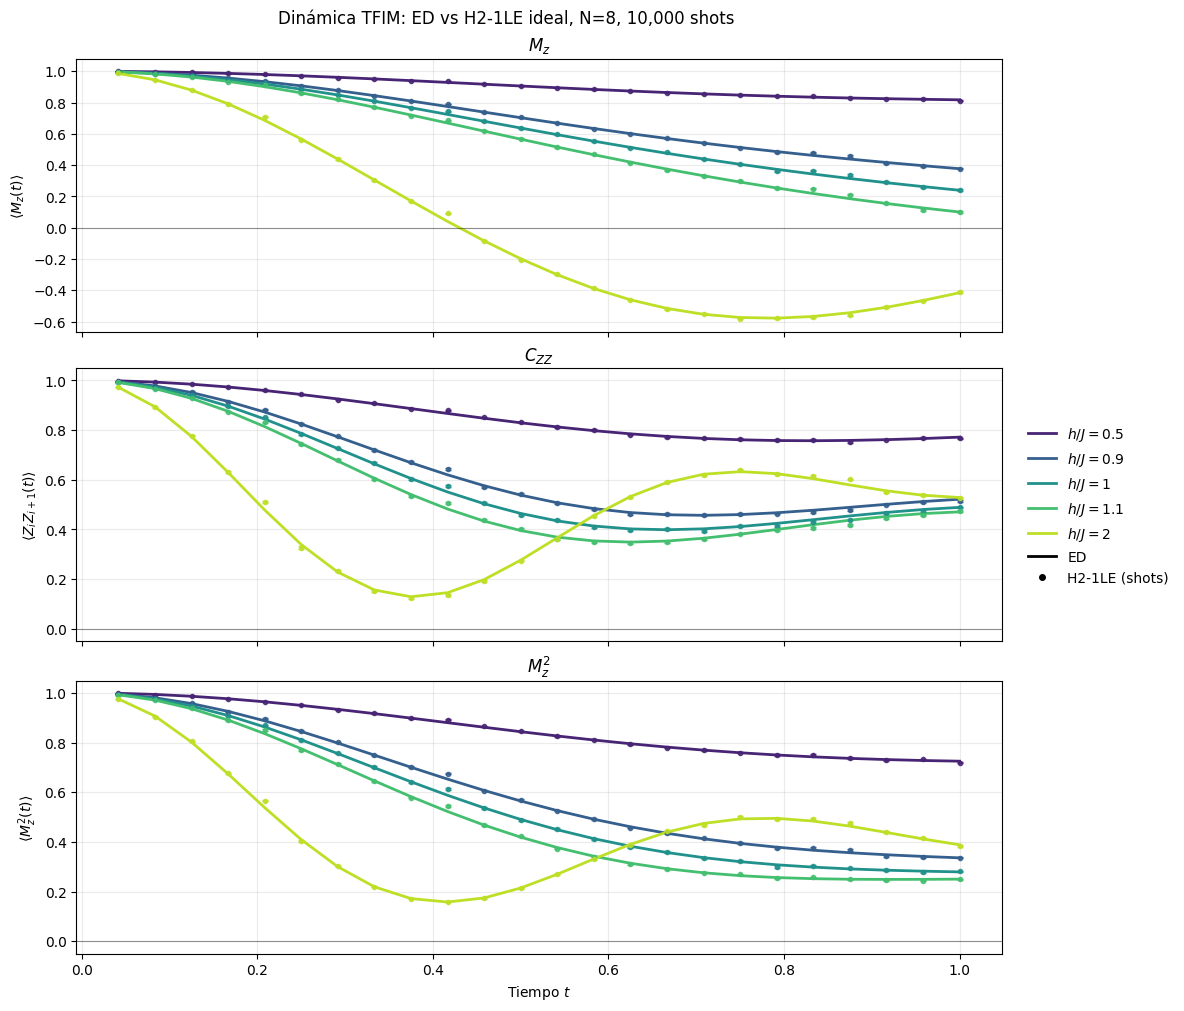

In [ ]:
from functools import lru_cache

import pandas as pd
from scipy.linalg import eigh


OBSERVABLE_KEYS = ("mz", "mz2", "czz")


@lru_cache(maxsize=None)
def exact_tfim_model(h: float, J: float, n: int):
    """Diagonalización y observables diagonales para un Hamiltoniano TFIM."""
    h = float(h)
    J = float(J)
    n = int(n)
    dimension = 2**n

    basis = np.arange(dimension, dtype=np.uint64)
    positions = np.arange(n, dtype=np.uint64)
    bits = ((basis[:, None] >> positions) & 1).astype(int)
    z_values = 1 - 2 * bits

    mz_values = np.mean(z_values, axis=1)
    mz2_values = mz_values**2
    czz_values = np.mean(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )
    zz_sum = np.sum(
        z_values[:, :-1] * z_values[:, 1:],
        axis=1,
    )

    hamiltonian = np.diag(-J * zz_sum).astype(complex)
    rows = np.arange(dimension)
    for site in range(n):
        flipped = basis ^ np.uint64(1 << site)
        hamiltonian[rows, flipped.astype(int)] -= h

    eigenvalues, eigenvectors = eigh(hamiltonian)
    initial_coefficients = eigenvectors[0].conj()

    return (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        mz_values,
        mz2_values,
        czz_values,
    )


@lru_cache(maxsize=None)
def exact_reference_observables(
    h: float,
    J: float,
    t: float,
    n: int,
) -> tuple[float, float, float]:
    (
        eigenvalues,
        eigenvectors,
        initial_coefficients,
        mz_values,
        mz2_values,
        czz_values,
    ) = exact_tfim_model(float(h), float(J), int(n))

    phases = np.exp(-1j * eigenvalues * float(t))
    psi_t = eigenvectors @ (phases * initial_coefficients)
    probabilities = np.abs(psi_t) ** 2

    return tuple(
        float(probabilities @ values)
        for values in (mz_values, mz2_values, czz_values)
    )


def exact_observables_grid(
    hj_ratios,
    times,
    J: float,
    n: int,
):
    ratios = np.asarray(hj_ratios, dtype=float)
    times = np.asarray(times, dtype=float)
    shape = (len(ratios), len(times))
    exact = {
        key: np.empty(shape, dtype=float)
        for key in OBSERVABLE_KEYS
    }

    for ratio_index, ratio in enumerate(ratios):
        for time_index, time in enumerate(times):
            values = exact_reference_observables(
                h=float(ratio * J),
                J=float(J),
                t=float(time),
                n=int(n),
            )
            for observable_index, key in enumerate(OBSERVABLE_KEYS):
                exact[key][ratio_index, time_index] = values[observable_index]

    return exact


def relative_error(simulated, exact, zero_tolerance=1e-12):
    if abs(exact) <= zero_tolerance:
        return np.nan
    return abs(simulated - exact) / abs(exact)


dynamics_figure, dynamics_axes = graph_h2_observables_in_time(
    execution_records=execution_records,
    hj_ratios=hj_ratios,
    times=times_simulator,
    J=J,
    n=n,
)
plt.show()


## 13) Convergencia de Trotter

ED frente a AerState en $t=1$, $2.5$ y $5$. Usar varios tiempos evita concluir a partir de una cancelación accidental del error en un único instante.


In [ ]:
def submit_or_resume_statevector_scan(
    circuits,
    scan_records,
    project,
    run_label,
    optimisation_level=0,
    force_new=False,
):
    run_directory = (
        None
        if force_new
        else latest_run_directory(run_label, required=False)
    )
    if run_directory is not None:
        execute_path = run_directory / "execute-job"
        compile_path = run_directory / "compile-job"
        if execute_path.exists():
            execute_job = qnx.filesystem.load(path=execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución AerState recuperada: {run_directory}")
            return run_directory
        if compile_path.exists():
            records = load_scan_records(run_directory)
            backend_config = qnx.AerStateConfig(
                n_qubits=max(int(record["n"]) for record in records),
            )
            compile_job = qnx.filesystem.load(path=compile_path)
            qnx.jobs.wait_for(compile_job)
            compiled_circuits = [
                result.get_output()
                for result in qnx.jobs.results(compile_job)
            ]
            execute_job = qnx.start_execute_job(
                programs=compiled_circuits,
                backend_config=backend_config,
                n_shots=[None] * len(compiled_circuits),
                name=f"{run_label}-execute-{run_directory.name}",
                project=project,
            )
            save_job_reference(execute_job, execute_path)
            qnx.jobs.wait_for(execute_job)
            print(f"Ejecución AerState reanudada: {run_directory}")
            return run_directory

    if len(circuits) != len(scan_records):
        raise ValueError(
            f"Se recibieron {len(circuits)} circuitos y "
            f"{len(scan_records)} registros."
        )
    if not circuits:
        raise ValueError("No hay circuitos para ejecutar.")

    run_suffix = datetime.datetime.now().strftime(
        "%Y_%m_%d-%H_%M_%S_%f"
    )
    run_directory = prepare_run_directory(
        run_label,
        run_suffix,
        scan_records,
    )
    backend_config = qnx.AerStateConfig(
        n_qubits=max(int(record["n"]) for record in scan_records),
    )

    circuit_refs = [
        qnx.circuits.upload(
            circuit=circuit,
            name=record["name"],
        )
        for circuit, record in tqdm(
            zip(circuits, scan_records, strict=True),
            total=len(circuits),
            desc="Subiendo circuitos AerState",
            unit="circuito",
        )
    ]

    compile_job = qnx.start_compile_job(
        programs=circuit_refs,
        backend_config=backend_config,
        optimisation_level=optimisation_level,
        name=f"{run_label}-compile-{run_suffix}",
        project=project,
    )
    save_job_reference(compile_job, run_directory / "compile-job")
    qnx.jobs.wait_for(compile_job)
    compiled_circuits = [
        result.get_output()
        for result in qnx.jobs.results(compile_job)
    ]

    execute_job = qnx.start_execute_job(
        programs=compiled_circuits,
        backend_config=backend_config,
        n_shots=[None] * len(compiled_circuits),
        name=f"{run_label}-execute-{run_suffix}",
        project=project,
    )
    save_job_reference(execute_job, run_directory / "execute-job")
    qnx.jobs.wait_for(execute_job)
    print(f"Ejecución AerState guardada: {run_directory}")
    return run_directory


trotter_step_values = np.array(
    [1, 2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
)
convergence_hj_ratios = np.array([0.5, 1.0, 2.0])
convergence_times = np.array([1.0, 2.5, 5.0])
convergence_n = 8
convergence_J = 1.0
CONVERGENCE_RUN_LABEL = "trotter-convergence-n8-v2"
FORCE_NEW_CONVERGENCE_RUN = False

convergence_circuits = []
convergence_records = []
saved_convergence_run = (
    None
    if FORCE_NEW_CONVERGENCE_RUN
    else latest_run_directory(CONVERGENCE_RUN_LABEL, required=False)
)
has_saved_convergence_job = (
    saved_convergence_run is not None
    and (
        (saved_convergence_run / "compile-job").exists()
        or (saved_convergence_run / "execute-job").exists()
    )
)

if not has_saved_convergence_job:
    for trotter_steps in tqdm(
        trotter_step_values,
        desc="Generando circuitos de convergencia",
        unit="steps",
    ):
        step_circuits, step_records, _ = generate_tfim_trotter_scan(
            hj_ratios=convergence_hj_ratios,
            times=convergence_times,
            J=convergence_J,
            steps=int(trotter_steps),
            n=convergence_n,
            measure=False,
            name_prefix=f"tfim-convergence-s{int(trotter_steps)}",
        )
        convergence_circuits.extend(step_circuits)
        convergence_records.extend(step_records)

convergence_run_dir = submit_or_resume_statevector_scan(
    circuits=convergence_circuits,
    scan_records=convergence_records,
    project=project,
    run_label=CONVERGENCE_RUN_LABEL,
    optimisation_level=0,
    force_new=FORCE_NEW_CONVERGENCE_RUN,
)


Generando circuitos de convergencia:   0%|          | 0/11 [00:00<?, ?steps/s]

Subiendo circuitos AerState:   0%|          | 0/99 [00:00<?, ?circuito/s]

Ejecución AerState guardada: /Users/anotherdev/workspace/quanthathon/project/qnexus_runs/trotter-convergence-n8-v2/2026_07_22-23_56_24_561964


### Resultados de convergencia

Esta celda recupera el job guardado; puede repetirse sin volver a ejecutarlo.


Usando resultados guardados: /Users/anotherdev/workspace/quanthathon/project/trotter_convergence_results.csv


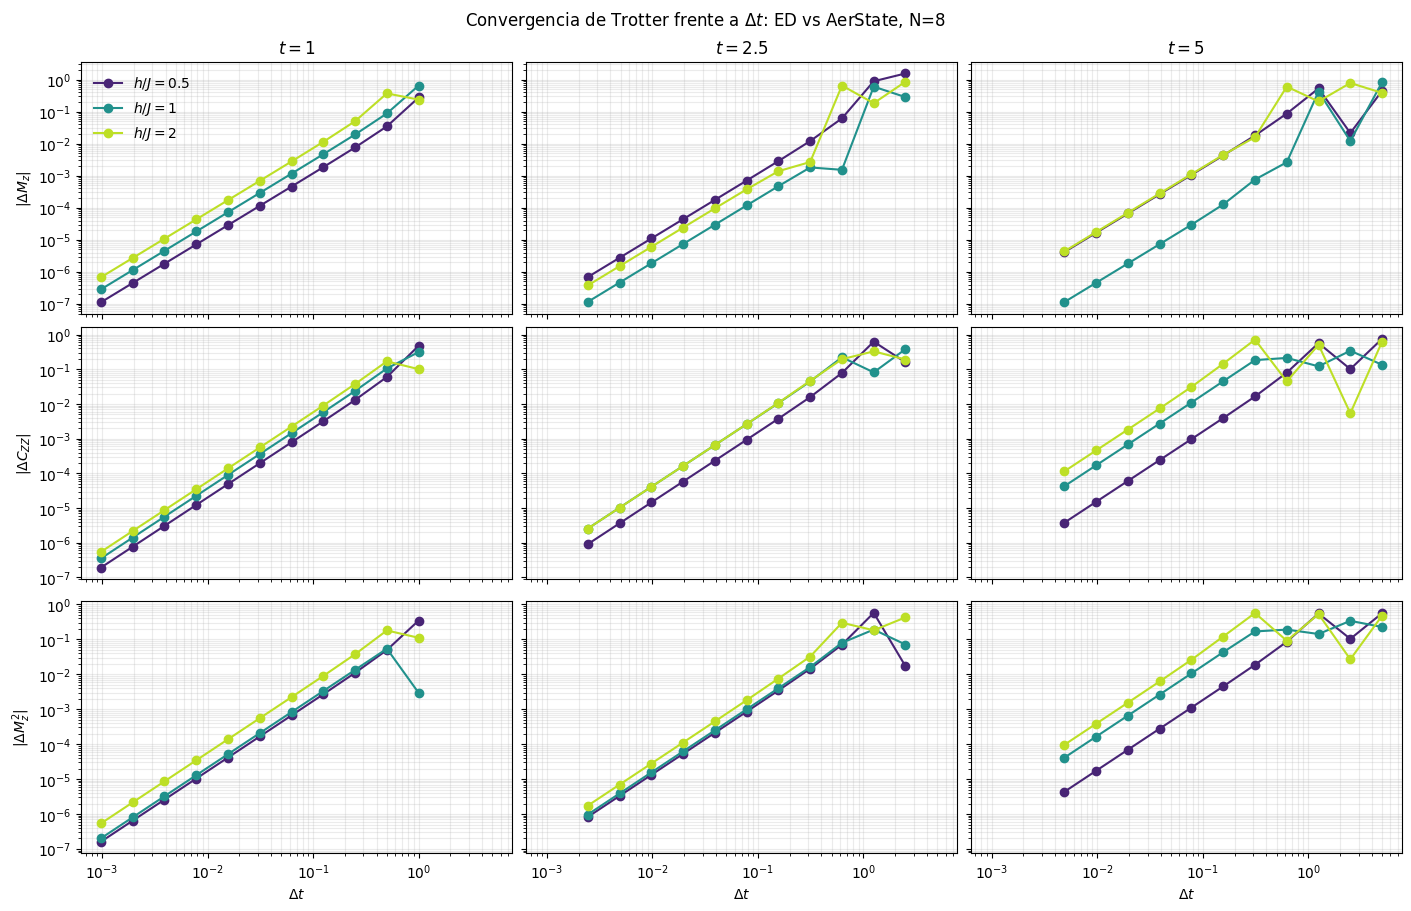

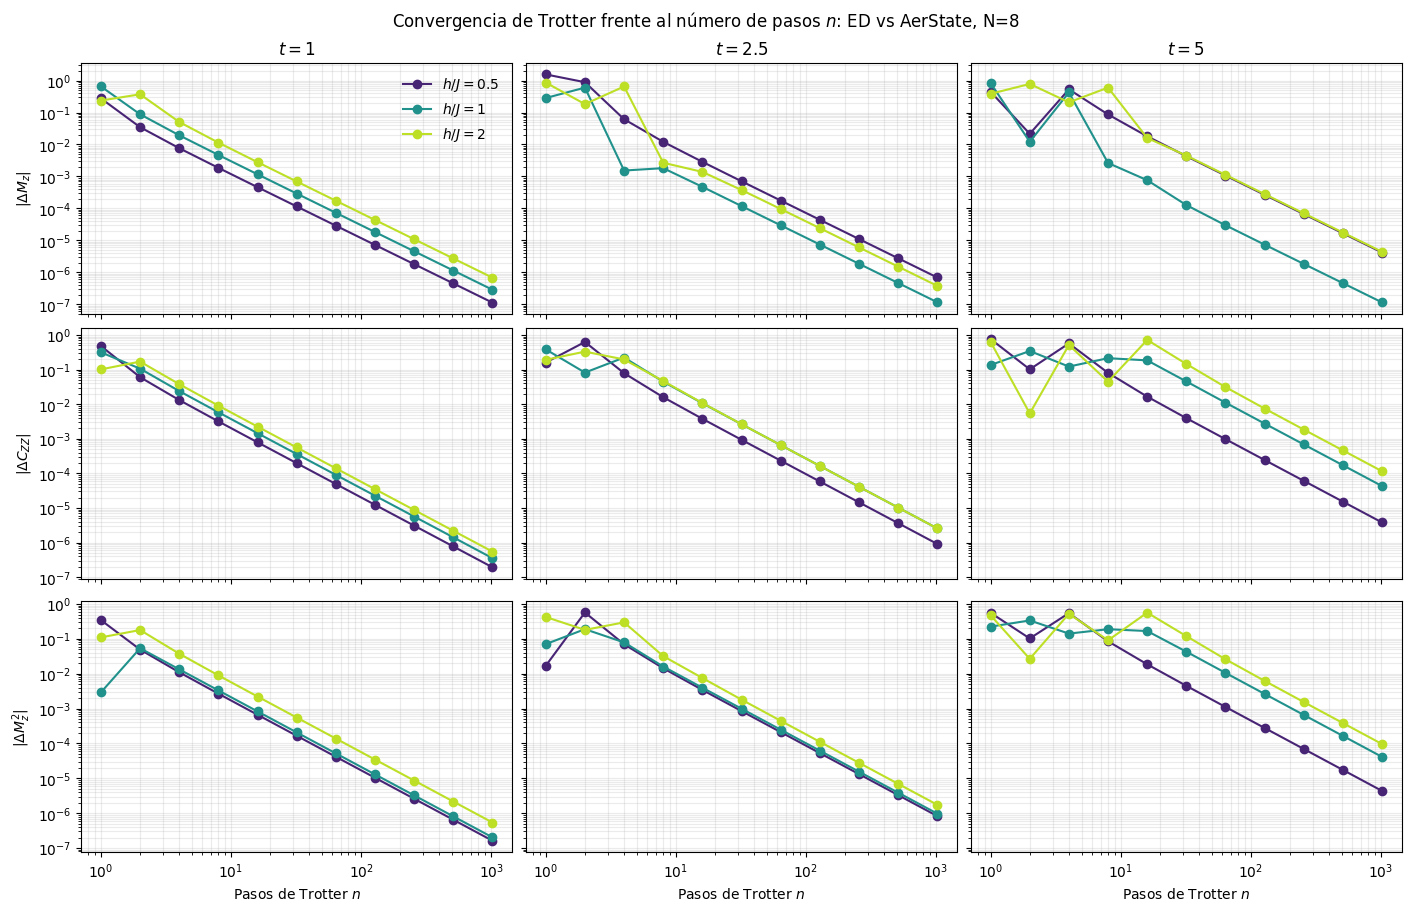

,h_over_J,time,trotter_steps,dt,sim_mz,exact_mz,abs_error_mz,sim_mz2,exact_mz2,abs_error_mz2,sim_czz,exact_czz,abs_error_czz
0,0.5,1.0,1,1.0000,0.540302,0.81759,0.277288,0.380436,0.725233,0.344797,0.291927,0.771564,0.479637
1,0.5,1.0,2,0.5000,0.782786,0.81759,0.034804,0.675886,0.725233,0.049347,0.711262,0.771564,0.060302
2,0.5,1.0,4,0.2500,0.809933,0.81759,0.007657,0.714223,0.725233,0.011010,0.758419,0.771564,0.013145
3,0.5,1.0,8,0.1250,0.815733,0.81759,0.001858,0.722554,0.725233,0.002679,0.768382,0.771564,0.003181
4,0.5,1.0,16,0.0625,0.817129,0.81759,0.000461,0.724568,0.725233,0.000665,0.770775,0.771564,0.000789


In [85]:
convergence_csv_path = Path.cwd() / "trotter_convergence_results.csv"

if convergence_csv_path.exists():
    convergence_df = pd.read_csv(convergence_csv_path)
    print(f"Usando resultados guardados: {convergence_csv_path}")
else:
    convergence_run_dir = latest_run_directory(CONVERGENCE_RUN_LABEL)
    convergence_execution_records = recover_execution_records(
        convergence_run_dir
    )

    rows = []
    for record in convergence_execution_records:
        sim_mz, sim_mz2, sim_czz = z_observables_from_probability_result(
            record["backend_result"],
            convergence_n,
        )
        exact_mz, exact_mz2, exact_czz = exact_reference_observables(
            h=record["ratio"] * convergence_J,
            J=convergence_J,
            t=record["time"],
            n=convergence_n,
        )
        rows.append(
            {
                "h_over_J": record["ratio"],
                "time": record["time"],
                "trotter_steps": record["steps"],
                "dt": record["dt"],
                "sim_mz": sim_mz,
                "exact_mz": exact_mz,
                "abs_error_mz": abs(sim_mz - exact_mz),
                "sim_mz2": sim_mz2,
                "exact_mz2": exact_mz2,
                "abs_error_mz2": abs(sim_mz2 - exact_mz2),
                "sim_czz": sim_czz,
                "exact_czz": exact_czz,
                "abs_error_czz": abs(sim_czz - exact_czz),
            }
        )

    convergence_df = (
        pd.DataFrame(rows)
        .sort_values(["time", "h_over_J", "trotter_steps"])
        .reset_index(drop=True)
    )
    convergence_df.to_csv(convergence_csv_path, index=False)


def plot_trotter_errors(
    convergence_df,
    x_column,
    x_label,
    title_suffix,
):
    figure, axes = plt.subplots(
        3,
        len(convergence_times),
        figsize=(14, 9),
        sharex=True,
        sharey="row",
        constrained_layout=True,
    )
    error_specs = [
        ("abs_error_mz", r"$|\Delta M_z|$"),
        ("abs_error_czz", r"$|\Delta C_{ZZ}|$"),
        ("abs_error_mz2", r"$|\Delta M_z^2|$"),
    ]
    colors = plt.cm.viridis(
        np.linspace(0.1, 0.9, len(convergence_hj_ratios))
    )

    for column, time in enumerate(convergence_times):
        time_data = convergence_df[
            np.isclose(convergence_df["time"], time)
        ]
        for row, (error_column, ylabel) in enumerate(error_specs):
            axis = axes[row, column]
            for color, ratio in zip(colors, convergence_hj_ratios):
                ratio_data = time_data[
                    np.isclose(time_data["h_over_J"], ratio)
                ].sort_values(x_column)
                axis.loglog(
                    ratio_data[x_column],
                    np.maximum(
                        ratio_data[error_column],
                        np.finfo(float).tiny,
                    ),
                    color=color,
                    marker="o",
                    linewidth=1.5,
                    label=fr"$h/J={ratio:.3g}$",
                )
            if row == 0:
                axis.set_title(fr"$t={time:g}$")
            if column == 0:
                axis.set_ylabel(ylabel)
            if row == len(error_specs) - 1:
                axis.set_xlabel(x_label)
            axis.grid(True, which="both", alpha=0.25)

    axes[0, 0].legend(frameon=False)
    figure.suptitle(
        f"Convergencia de Trotter {title_suffix}: "
        f"ED vs AerState, N={convergence_n}"
    )
    return figure, axes


convergence_dt_figure, convergence_dt_axes = plot_trotter_errors(
    convergence_df,
    x_column="dt",
    x_label=r"$\Delta t$",
    title_suffix=r"frente a $\Delta t$",
)
plt.show()

convergence_steps_figure, convergence_steps_axes = plot_trotter_errors(
    convergence_df,
    x_column="trotter_steps",
    x_label=r"Pasos de Trotter $n$",
    title_suffix=r"frente al número de pasos $n$",
)
plt.show()

convergence_df.head()
